# Notebook 02: Token and Positional Embeddings

## Overview

- **Duration**: ~2.5 hours
- **Prerequisites**: Notebook 01 (Tokenization), basic PyTorch
- **Learning Objectives**:
  1. Understand the role of embeddings in neural networks
  2. Implement token embedding layers
  3. Implement sinusoidal and learned positional encodings
  4. Visualize and analyze embedding spaces

## Introduction

After tokenization, we have sequences of integer IDs. But neural networks work with continuous vectors. **Embeddings** convert discrete tokens into dense vector representations.

### Why Embeddings?

- **One-hot encoding** is sparse and high-dimensional (vocab_size dimensions)
- **Embeddings** are dense and learnable (typically 256-4096 dimensions)
- Similar tokens can have similar embeddings (learned during training)

### Why Positional Encodings?

Unlike RNNs, transformers process all tokens in parallel. They have no inherent notion of position. We must explicitly add positional information.

Two main approaches:
1. **Sinusoidal** (fixed): Deterministic patterns based on position
2. **Learned** (trainable): Position embeddings learned during training

## 1. Setup

In [1]:
###%pip install seaborn

import sys
sys.path.insert(0, '../..')

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Load tokenizer from Notebook 01 (or use shared module)
try:
    import pickle
    from pathlib import Path
    
    # define a minimal dummy class to pickle the tokenizer
    class BasicTokenizer:   # Must match the original class name
        pass
    
    tokenizer_path = Path("tokenizer.pkl")
    if tokenizer_path.exists():
        with open(tokenizer_path, "rb") as f:
            tokenizer = pickle.load(f)
        print(f"Loaded tokenizer with vocab size: {len(tokenizer.vocab)}")
    else:
        raise FileNotFoundError("Tokenizer not found")
except:
    print("Using shared tokenizer module...")
    from shared.tokenizer import BPETokenizer
    tokenizer = BPETokenizer()
    # Train a small tokenizer for demonstration
    sample_text = "The quick brown fox jumps over the lazy dog. " * 100
    tokenizer.train(sample_text, vocab_size=500)
    print(f"Trained tokenizer with vocab size: {len(tokenizer.vocab)}")

Loaded tokenizer with vocab size: 2000


## 2. Understanding One-Hot vs Dense Embeddings

In [13]:
# One-hot encoding example
vocab_size = 10
token_id = 3

# Create one-hot vector
one_hot = torch.zeros(vocab_size)
one_hot[token_id] = 1.0

print(f"One-hot encoding for token {token_id}:")
print(one_hot)
print(f"\nProperties:")
print(f"  - Dimension: {vocab_size}")
print(f"  - Sparsity: {(one_hot == 0).sum().item() / vocab_size * 100:.1f}% zeros")

One-hot encoding for token 3:
tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

Properties:
  - Dimension: 10
  - Sparsity: 90.0% zeros


In [14]:
# Dense embedding example
embedding_dim = 4

# Create a simple embedding layer
embedding_layer = nn.Embedding(vocab_size, embedding_dim)

# Get embedding for token 3
token_tensor = torch.tensor([token_id])
dense_embedding = embedding_layer(token_tensor)

print(f"Dense embedding for token {token_id}:")
print(dense_embedding)
print(f"\nProperties:")
print(f"  - Dimension: {embedding_dim}")
print(f"  - All values are non-zero and learnable")

Dense embedding for token 3:
tensor([[-0.2381,  2.3713,  1.5908,  0.5726]], grad_fn=<EmbeddingBackward0>)

Properties:
  - Dimension: 4
  - All values are non-zero and learnable


## 3. Exercises

### Exercise 3.1: Token Embedding Layer (20 min)

Implement a token embedding layer that converts token IDs to dense vectors.
- replace the TODO parts with your code.

In [ ]:
####solution 3.1
class TokenEmbedding(nn.Module):
    """
    Token embedding layer that converts token IDs to dense vectors.
    
    Args:
        vocab_size: Size of the vocabulary
        d_model: Dimension "embedding_dim" of the embedding vectors
    """
    
    def __init__(self, vocab_size: int, d_model: int):
        super().__init__()
        # TODO: Create an embedding layer using nn.Embedding
        # TODO: The embedding should map from vocab_size to d_model dimensions
        self.embedding = nn.Embedding(vocab_size, d_model)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Token IDs of shape (batch_size, seq_len)
            
        Returns:
            Embeddings of shape (batch_size, seq_len, d_model)
        """
        # TODO: Return the embeddings for the input tokens
        dense_embedding = self.embedding(x)
        return dense_embedding
        

In [5]:
####test cell
# Test your implementation
vocab_size = 1000
d_model = 64
batch_size = 2
seq_len = 10

token_emb = TokenEmbedding(vocab_size, d_model)

# Create random input tokens
input_ids = torch.randint(0, vocab_size, (batch_size, seq_len))
print(f"Input shape: {input_ids.shape}")

# Get embeddings
embeddings = token_emb(input_ids)
print(f"Output shape: {embeddings.shape}")

# Validation
assert embeddings.shape == (batch_size, seq_len, d_model), \
    f"Expected shape {(batch_size, seq_len, d_model)}, got {embeddings.shape}"
print("\n✓ Exercise 3.1 passed!")

Input shape: torch.Size([2, 10])
Output shape: torch.Size([2, 10, 64])

✓ Exercise 3.1 passed!


### Exercise 3.2: Sinusoidal Positional Encoding (40 min)

Implement the sinusoidal positional encoding from "Attention Is All You Need".

The formula is:
- PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
- PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

Where:
- `pos` is the position in the sequence
- `i` is the dimension index
- `d_model` is the embedding dimension

In [44]:
####solution 3.2
class SinusoidalPositionalEncoding(nn.Module):
    """Sinusoidal positional encoding from 'Attention Is All You Need'."""
    
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # TODO: Create the positional encoding matrix
        # 1. Create a matrix of shape (max_len, d_model)
        pe = torch.zeros(max_len, d_model)
        # 2. Create position indices: [0, 1, 2, ..., max_len-1]
        position = torch.arange(0, max_len).unsqueeze(1)
        #print(position)
        # 3. Create dimension indices for the division term
        dimension = torch.arange(0, d_model, 2)
        #print(dimension)
        # 4. Compute div_term = exp(-log(10000) * 2i / d_model)
        #    This is equivalent to 1 / 10000^(2i/d_model)
        div_term = torch.exp(-torch.log(torch.tensor(10000.0)) * dimension / d_model)
        # 5. Apply sin to even indices, cos to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        # 6. Register as a buffer (not a parameter)
        self.register_buffer('pe', pe.unsqueeze(0))
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Add positional encoding to input embeddings."""
        # TODO: Add positional encoding to x
        # Only use the first seq_len positions
        seq_len = x.size(1)
        x = x + self.pe[:,:seq_len, :]
        return self.dropout(x)

In [45]:
####test cell
# Test your implementation
d_model = 64
max_len = 100

pos_enc = SinusoidalPositionalEncoding(d_model, max_len, dropout=0.0)

# Create zero input to see just the positional encoding
x = torch.zeros(1, 50, d_model)
output = pos_enc(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

# Validation
assert output.shape == x.shape, f"Shape mismatch"
assert not torch.allclose(output, x), "Output should not be all zeros"
print("\n✓ Exercise 3.2 passed!")

Input shape: torch.Size([1, 50, 64])
Output shape: torch.Size([1, 50, 64])

✓ Exercise 3.2 passed!


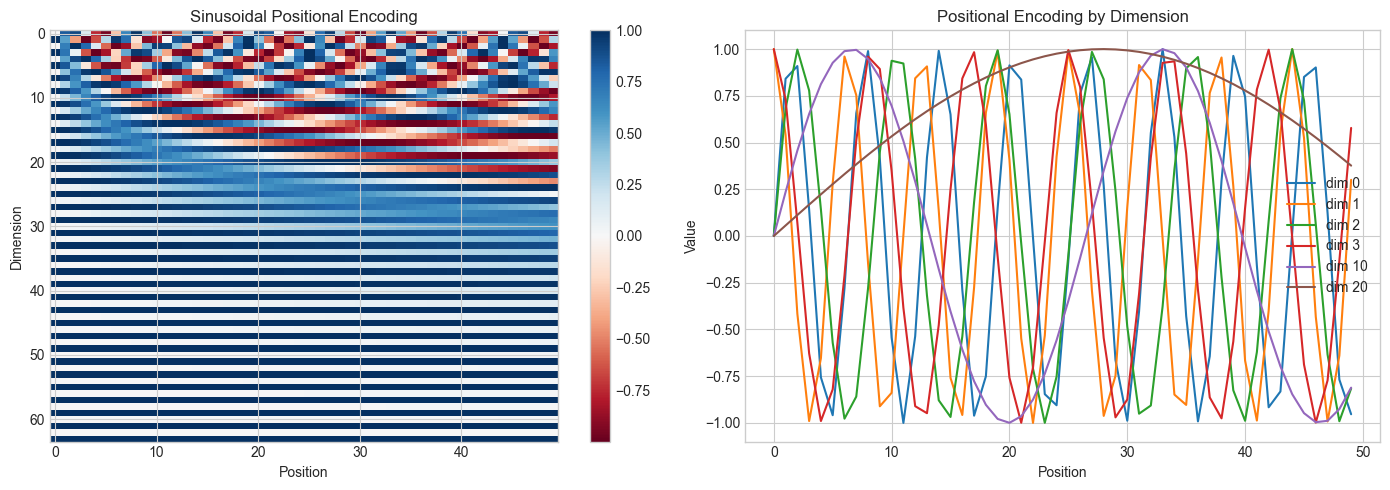

In [46]:
####plotting cell
# Visualize the positional encoding
pe_matrix = pos_enc.pe[0, :50, :].numpy()  # Get first 50 positions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
ax = axes[0]
im = ax.imshow(pe_matrix.T, aspect='auto', cmap='RdBu')
ax.set_xlabel('Position')
ax.set_ylabel('Dimension')
ax.set_title('Sinusoidal Positional Encoding')
plt.colorbar(im, ax=ax)

# Line plot for a few dimensions
ax = axes[1]
positions = np.arange(50)
for dim in [0, 1, 2, 3, 10, 20]:
    ax.plot(positions, pe_matrix[:, dim], label=f'dim {dim}')
ax.set_xlabel('Position')
ax.set_ylabel('Value')
ax.set_title('Positional Encoding by Dimension')
ax.legend()

plt.tight_layout()
plt.show()

### Exercise 3.3: Learned Positional Embeddings (20 min)

GPT-2 and many modern transformers use learned positional embeddings instead of sinusoidal.

This is simply another embedding layer that maps position indices to vectors.

In [52]:
####solution 3.3
class LearnedPositionalEmbedding(nn.Module):
    """
    Learned positional embedding (like GPT-2).
    
    Args:
        max_len: Maximum sequence length
        d_model: Dimension of the model
    """
    
    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        # TODO: Create an embedding layer for positions
        # This should map from max_len positions to d_model dimensions
        self.embedding = nn.Embedding(max_len, d_model)
        
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Add positional embeddings to input.
        
        Args:
            x: Input tensor of shape (batch_size, seq_len, d_model)
            
        Returns:
            Tensor with positional embeddings added
        """
        # TODO: 
        # 1. Get the sequence length from x
        # 2. Create position indices [0, 1, 2, ..., seq_len-1]
        # 3. Get position embeddings
        # 4. Add to x and return
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device)
        x = x + self.embedding(positions)
        return x

In [53]:
####test cell
# Test your implementation
max_len = 512
d_model = 64

learned_pos = LearnedPositionalEmbedding(max_len, d_model)

x = torch.randn(2, 50, d_model)
output = learned_pos(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

# Validation
assert output.shape == x.shape
assert not torch.allclose(output, x), "Output should be different from input"
print("\n✓ Exercise 3.3 passed!")

Input shape: torch.Size([2, 50, 64])
Output shape: torch.Size([2, 50, 64])

✓ Exercise 3.3 passed!


### Exercise 3.4: Combined Embedding Module (15 min)

Create a module that combines token embeddings and positional encodings.

In [63]:
####solution 3.4
class TransformerEmbedding(nn.Module):
    """
    Combined token and positional embedding for transformers.
    
    Args:
        vocab_size: Size of vocabulary
        d_model: Embedding dimension
        max_len: Maximum sequence length
        dropout: Dropout probability
        use_learned_pos: If True, use learned positional embeddings
    """
    
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        max_len: int = 512,
        dropout: float = 0.1,
        use_learned_pos: bool = True,
    ):
        super().__init__()
        # TODO:
        # 1. Create token embedding layer
        self.token_emb = TokenEmbedding(vocab_size, d_model)
        # 2. Create positional encoding (learned or sinusoidal based on flag)
        if use_learned_pos:
            self.positional_encoding = LearnedPositionalEmbedding(max_len, d_model)
        else:
            self.positional_encoding = SinusoidalPositionalEncoding(d_model, max_len)
        # 3. Create dropout layer
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Token IDs of shape (batch_size, seq_len)
            
        Returns:
            Embeddings of shape (batch_size, seq_len, d_model)
        """
        # TODO:
        # 1. Get token embeddings
        layer0 = self.token_emb(x)
        # 2. Add positional encoding
        layer1 = self.positional_encoding(layer0)
        # 3. Apply dropout
        layer2 = self.dropout(layer1)
        return layer2

In [64]:
####test cell
# Test your implementation
vocab_size = 1000
d_model = 64
max_len = 512

embedding = TransformerEmbedding(vocab_size, d_model, max_len, dropout=0.1)

input_ids = torch.randint(0, vocab_size, (2, 50))
output = embedding(input_ids)

print(f"Input shape: {input_ids.shape}")
print(f"Output shape: {output.shape}")

assert output.shape == (2, 50, d_model)
print("\n✓ Exercise 3.4 passed!")

Input shape: torch.Size([2, 50])
Output shape: torch.Size([2, 50, 64])

✓ Exercise 3.4 passed!


## 4. Embedding Visualization and Analysis

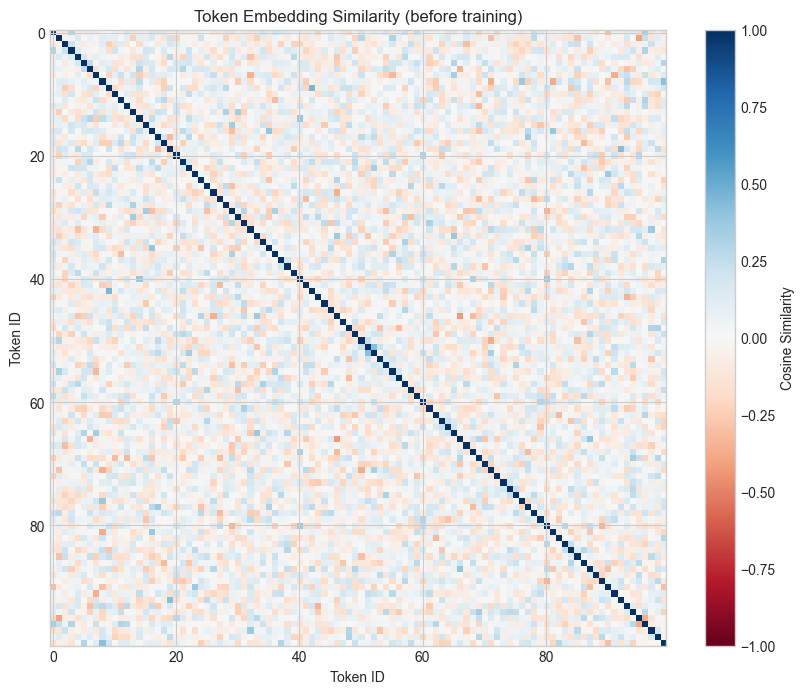

In [65]:
####ploting cell
###%pip install scikit-learn
# Visualize embedding similarity
from sklearn.metrics.pairwise import cosine_similarity

# Get embeddings for first 100 tokens
embedding_layer = TransformerEmbedding(vocab_size, d_model, max_len, dropout=0.0)

token_ids = torch.arange(100).unsqueeze(0)  # Shape: (1, 100)
with torch.no_grad():
    # Get just token embeddings (before positional encoding)
    token_embeds = embedding_layer.token_emb(token_ids).squeeze(0).numpy()

# Compute cosine similarity
sim_matrix = cosine_similarity(token_embeds)

plt.figure(figsize=(10, 8))
plt.imshow(sim_matrix, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(label='Cosine Similarity')
plt.xlabel('Token ID')
plt.ylabel('Token ID')
plt.title('Token Embedding Similarity (before training)')
plt.show()

Exception in thread Thread-44 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Morit\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\Morit\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Morit\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Users\Morit\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 109: character maps to <undefined>


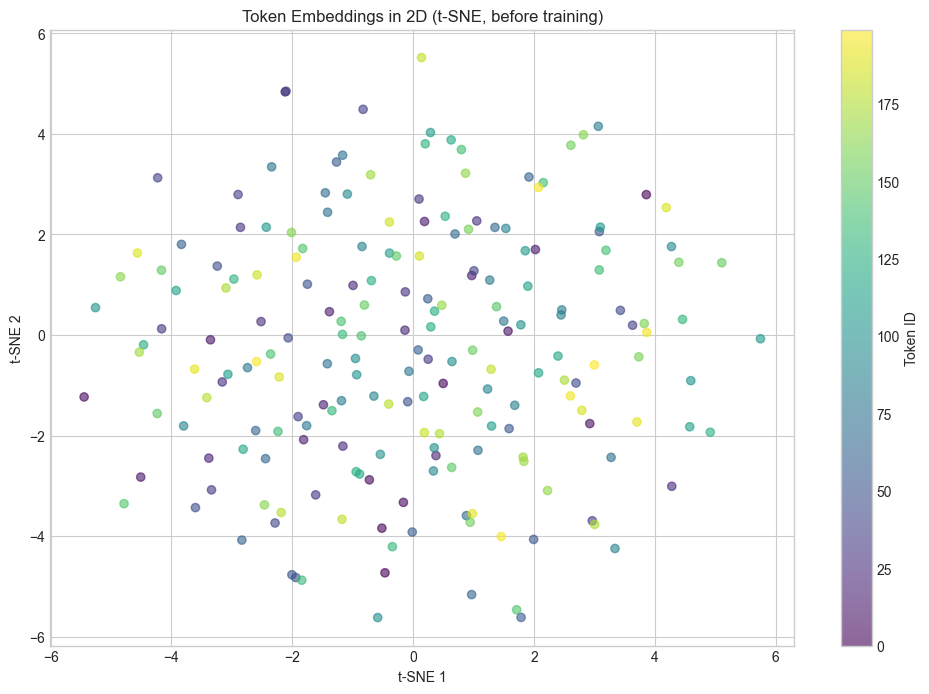

In [70]:
####ploting cell
# Visualize embeddings in 2D using t-SNE
from sklearn.manifold import TSNE

# Use first 200 tokens
n_tokens = 200
token_ids = torch.arange(n_tokens).unsqueeze(0)

with torch.no_grad():
    embeds = embedding_layer.token_emb(token_ids).squeeze(0).numpy()

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeds_2d = tsne.fit_transform(embeds)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(embeds_2d[:, 0], embeds_2d[:, 1], c=range(n_tokens), cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Token ID')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Token Embeddings in 2D (t-SNE, before training)')
plt.show()

## 5. Analysis Questions

Think about and discuss:

1. **Why do we scale embeddings?** Some implementations multiply embeddings by √d_model. Why might this help?

2. **Sinusoidal vs Learned**: What are the advantages of each approach?
   - Sinusoidal: Can generalize to longer sequences than seen during training
   - Learned: More flexible, can learn task-specific patterns

3. **Why use the same dimension for token and positional embeddings?** This allows simple addition.

## 6. Challenge: Rotary Positional Embeddings (RoPE) - Optional

Modern models like LLaMA use Rotary Positional Embeddings. Instead of adding position information, RoPE rotates the query and key vectors based on their position.

This is more complex but allows better extrapolation to longer sequences.

source: https://medium.com/ai-insights-cobet/rotary-positional-embeddings-a-detailed-look-and-comprehensive-understanding-4ff66a874d83

Testing RoPE implementation:

Input shape: torch.Size([2, 10, 8, 64])
Frequencies shape: torch.Size([512, 32])
Output shape: torch.Size([2, 10, 8, 64])

✓ RoPE implementation works!


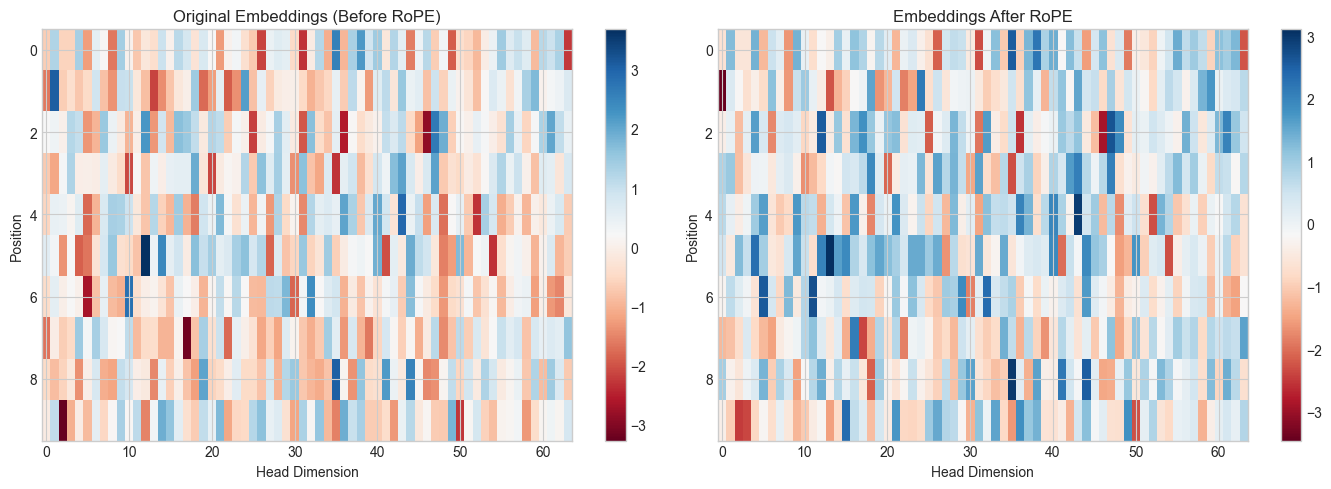


Key advantages of RoPE:
1. Position info encoded through rotation (not addition)
2. Naturally captures relative positions
3. Better extrapolation to longer sequences
4. Used in modern models: LLaMA, GPT-NeoX, PaLM
Yani Zhao:
RoPE is covered in more advanced materials. For now, learned positional embeddings work well!


In [69]:
# Simplified RoPE implementation (for reference)
'''def apply_rope(x: torch.Tensor, freqs_cis: torch.Tensor) -> torch.Tensor:
    """
    Apply rotary positional embeddings.
    
    Args:
        x: Input tensor of shape (batch, seq_len, n_heads, head_dim)
        freqs_cis: Complex frequencies of shape (seq_len, head_dim/2)
    """
    # This is a simplified version - full implementation is in shared/model.py
    # Key idea: treat pairs of dimensions as complex numbers and rotate them
    pass'''

def precompute_freqs_cis(head_dim: int, max_seq_len: int, theta: float = 10000.0) -> torch.Tensor:
    """
    Precompute the frequency tensor for complex exponentials (cis).
    
    Args:
        head_dim: Dimension of each attention head
        max_seq_len: Maximum sequence length
        theta: Base for exponential (default 10000)
        
    Returns:
        Complex tensor of shape (max_seq_len, head_dim/2)
    """
    # Compute frequencies for each dimension pair
    freqs = 1.0 / (theta ** (torch.arange(0, head_dim, 2).float() / head_dim))
    
    # Create position indices
    t = torch.arange(max_seq_len, dtype=torch.float32)
    
    # Outer product: (max_seq_len, head_dim/2)
    freqs = torch.outer(t, freqs)
    
    # Convert to complex exponentials: e^(i*theta) = cos(theta) + i*sin(theta)
    freqs_cis = torch.polar(torch.ones_like(freqs), freqs)  # (max_seq_len, head_dim/2)
    
    return freqs_cis


def reshape_for_broadcast(freqs_cis: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """
    Reshape freqs_cis to be broadcastable with x.
    
    Args:
        freqs_cis: (seq_len, head_dim/2)
        x: (batch, seq_len, n_heads, head_dim)
        
    Returns:
        freqs_cis: (1, seq_len, 1, head_dim/2)
    """
    ndim = x.ndim
    assert 0 <= 1 < ndim
    assert freqs_cis.shape == (x.shape[1], x.shape[-1] // 2)
    
    # Reshape to (1, seq_len, 1, head_dim/2) for broadcasting
    shape = [d if i == 1 or i == ndim - 1 else 1 for i, d in enumerate(x.shape)]
    shape[-1] = shape[-1] // 2  # Only half the dimensions
    
    return freqs_cis.view(*shape)


def apply_rope(x: torch.Tensor, freqs_cis: torch.Tensor) -> torch.Tensor:
    """
    Apply rotary positional embeddings to 4D tensor.
    
    Args:
        x: Input tensor of shape (batch, seq_len, n_heads, head_dim)
        freqs_cis: Complex frequencies of shape (seq_len, head_dim/2)
        
    Returns:
        Tensor with RoPE applied, same shape as input
    """
    # Convert input to complex numbers (treat pairs of dimensions as complex)
    # Reshape to (batch, seq_len, n_heads, head_dim/2, 2) then to complex
    x_reshaped = x.float().reshape(*x.shape[:-1], -1, 2)
    x_complex = torch.view_as_complex(x_reshaped)  # (batch, seq_len, n_heads, head_dim/2)
    
    # Reshape freqs_cis for broadcasting
    freqs_cis = reshape_for_broadcast(freqs_cis, x)  # (1, seq_len, 1, head_dim/2)
    
    # Apply rotation: multiply complex numbers
    x_rotated = x_complex * freqs_cis
    
    # Convert back to real numbers
    x_out = torch.view_as_real(x_rotated)  # (batch, seq_len, n_heads, head_dim/2, 2)
    x_out = x_out.reshape(*x.shape)  # (batch, seq_len, n_heads, head_dim)
    
    return x_out.type_as(x)


# Test the implementation
print("Testing RoPE implementation:\n")

batch_size = 2
seq_len = 10
n_heads = 8
head_dim = 64

# Create sample input
x = torch.randn(batch_size, seq_len, n_heads, head_dim)
print(f"Input shape: {x.shape}")

# Precompute frequencies
freqs_cis = precompute_freqs_cis(head_dim, max_seq_len=512)
print(f"Frequencies shape: {freqs_cis.shape}")

# Apply RoPE
x_rope = apply_rope(x, freqs_cis[:seq_len])
print(f"Output shape: {x_rope.shape}")

# Verify shape preservation
assert x_rope.shape == x.shape, "Shape should be preserved"
print("\n✓ RoPE implementation works!")

# Visualize rotation effect
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original embeddings (first head, first sample)
ax = axes[0]
im = ax.imshow(x[0, :, 0, :].detach().numpy(), aspect='auto', cmap='RdBu')
ax.set_xlabel('Head Dimension')
ax.set_ylabel('Position')
ax.set_title('Original Embeddings (Before RoPE)')
plt.colorbar(im, ax=ax)

# After RoPE
ax = axes[1]
im = ax.imshow(x_rope[0, :, 0, :].detach().numpy(), aspect='auto', cmap='RdBu')
ax.set_xlabel('Head Dimension')
ax.set_ylabel('Position')
ax.set_title('Embeddings After RoPE')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("\nKey advantages of RoPE:")
print("1. Position info encoded through rotation (not addition)")
print("2. Naturally captures relative positions")
print("3. Better extrapolation to longer sequences")
print("4. Used in modern models: LLaMA, GPT-NeoX, PaLM")
print("Yani Zhao:")
print("RoPE is covered in more advanced materials. For now, learned positional embeddings work well!")

## 7. Summary

### What You Learned

1. **Token Embeddings**: Convert discrete tokens to continuous vectors
2. **Positional Encodings**: Add position information to embeddings
3. **Sinusoidal Encoding**: Fixed, deterministic, generalizes to longer sequences
4. **Learned Embeddings**: Trainable, more flexible

### Key Formulas

- Sinusoidal: PE(pos, 2i) = sin(pos / 10000^(2i/d))
- Combined: output = Dropout(TokenEmbed(x) + PosEmbed(positions))

### Preparation for Next Notebook

In Notebook 03, we'll implement the **attention mechanism** - the core innovation of transformers!